### Creation of pickles for 
- MinMaxScaler() - "scaler"
- PCA - "pca'
- kmeans model 'kmeans' 

In [5]:
#import relevant packages
import os
import librosa
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from sklearn.preprocessing import MinMaxScaler



# Model Training &  saving pickles
(training model on 3 sec csv file, stored in raw data)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df = pd.read_csv("../raw_data/Data/features_3_sec.csv") 

# Step 1: Features
X_features = df.drop(["label", "filename", "length"], axis = 1)

# Step 2: Feature Scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_features), columns = X_features.columns)

# Step 3: Applying PCA
pca = PCA(n_components=24) 
X_pca = pca.fit_transform(X_scaled)

# Step 4: Applying K-Means with optimal K, saving it as 'model'
optimal_k = 6
kmeans_clustering = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans = kmeans_clustering.fit(X_pca)

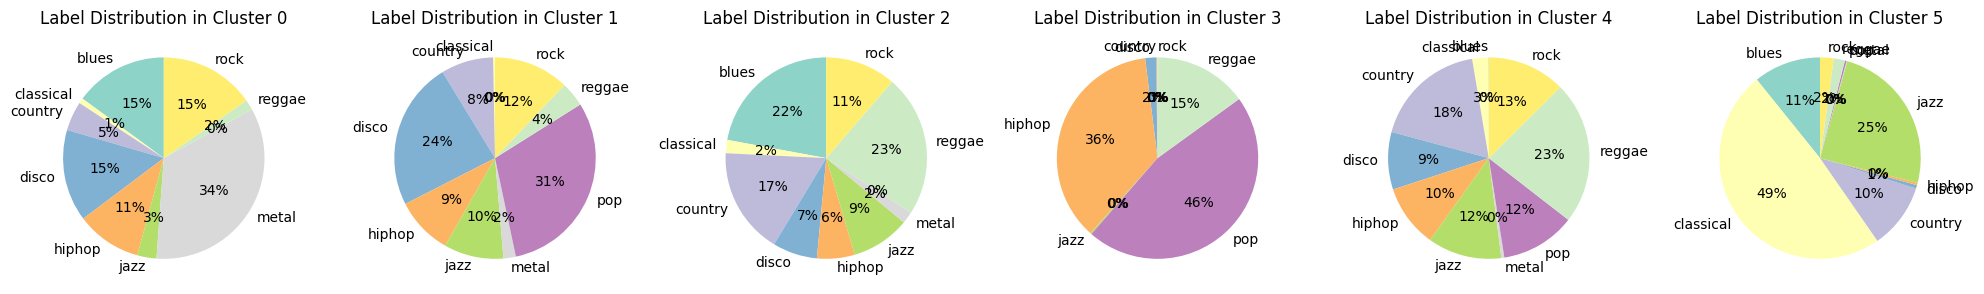

In [50]:
cluster_labels = kmeans.fit_predict(X_pca)
df["cluster"] = cluster_labels
comparison_table = pd.crosstab(df["label"], df["cluster"])
#comparison_table = pd.crosstab(df["spectral_centroid_mean"], df["cluster"], values=df["spectral_centroid_mean"], aggfunc='mean')
comparison_table_percentage = comparison_table.div(comparison_table.sum(axis=0), axis=1) * 100
fig, axes = plt.subplots(nrows=1, ncols=len(comparison_table_percentage.columns), figsize=(20, 10))
for i, cluster in enumerate(comparison_table_percentage.columns):
    comparison_table_percentage[cluster].plot.pie(ax=axes[i], autopct="%1.0f%%", startangle=90, cmap="Set3")
    axes[i].set_title(f"Label Distribution in Cluster {cluster}")
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

In [58]:
# Assuming df is your DataFrame
#average_spectral_centroid_per_cluster = df.groupby("cluster")["spectral_centroid_mean"].mean()
#print(average_spectral_centroid_per_cluster)

df_scaled = X_scaled.copy()
df_scaled["cluster"] = df["cluster"]
numeric_columns = df_scaled.select_dtypes(include=["int", "float"]).columns
# Group by "cluster" and calculate the mean for numeric columns
average_per_cluster = df_scaled.groupby("cluster")[numeric_columns].mean()
print(average_per_cluster)

         chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
cluster                                                          
0                0.504547         0.596206  0.327036  0.054067   
1                0.488626         0.627828  0.393966  0.091254   
2                0.392093         0.713848  0.253374  0.073943   
3                0.500905         0.722923  0.487399  0.318098   
4                0.410189         0.677794  0.258853  0.056603   
5                0.262416         0.670966  0.145336  0.027440   

         spectral_centroid_mean  spectral_centroid_var  \
cluster                                                  
0                      0.393943               0.047010   
1                      0.540927               0.109011   
2                      0.250314               0.084828   
3                      0.519542               0.258983   
4                      0.344632               0.120081   
5                      0.155108               0.020151   

      

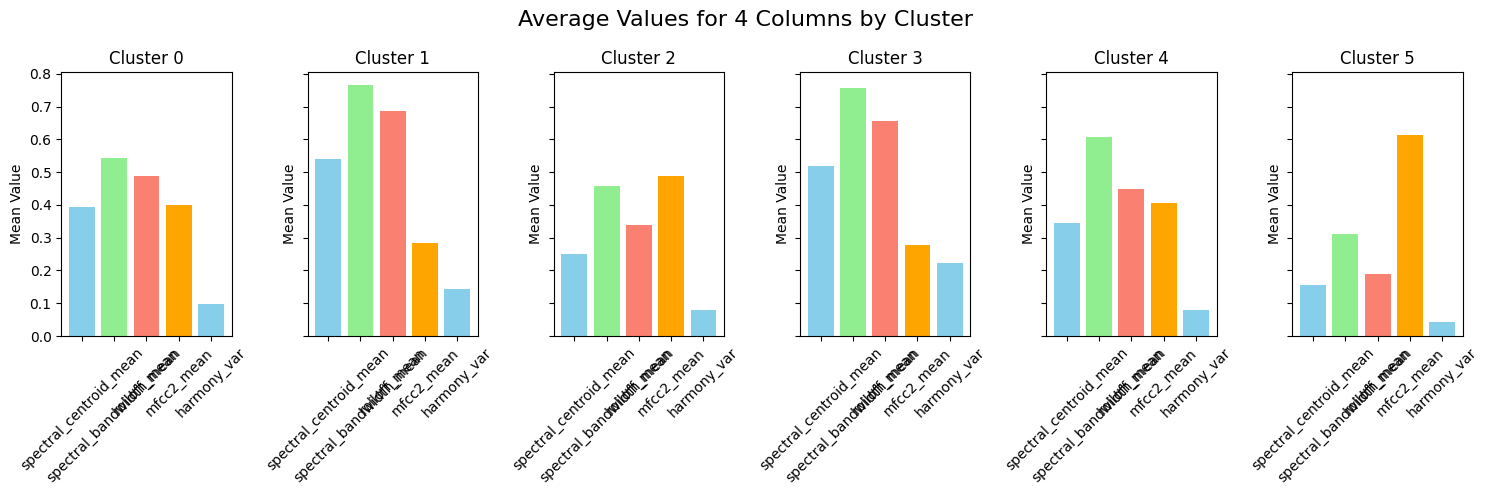

In [64]:
import matplotlib.pyplot as plt

# Select few columns to visualize
columns_to_visualize = ["spectral_centroid_mean", "spectral_bandwidth_mean", "rolloff_mean", "mfcc2_mean", "harmony_var"]

# Number of clusters
clusters = average_per_cluster.index

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(clusters), figsize=(15, 5), sharey=True)

# Plot for each cluster
for i, cluster in enumerate(clusters):
    # Select data for the current cluster
    cluster_data = average_per_cluster.loc[cluster, columns_to_visualize]
    
    # Create a bar plot for the current cluster
    axes[i].bar(columns_to_visualize, cluster_data, color=["skyblue", "lightgreen", "salmon", "orange"])
    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylabel("Mean Value")
    axes[i].tick_params(axis="x", rotation=45)

# Add a title to the entire figure
plt.suptitle("Average Values for 4 Columns by Cluster", fontsize=16)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()
fig.savefig("5features-cluster.pdf")

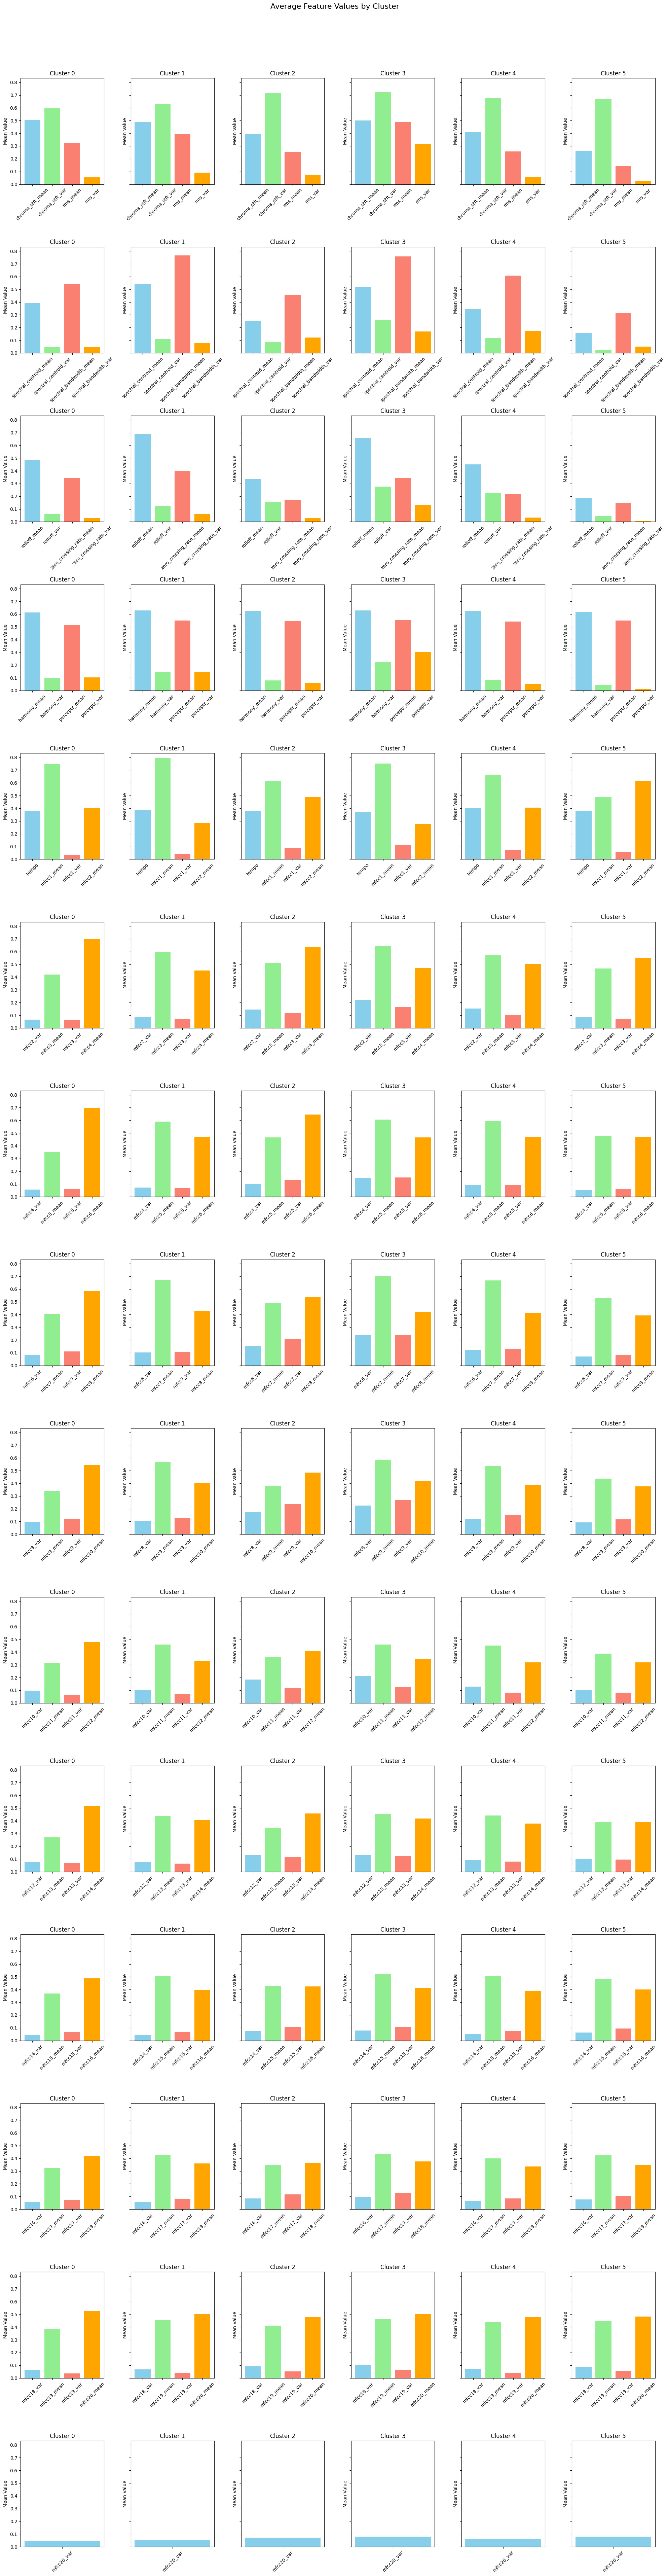

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# List of all feature names
features = [
    "chroma_stft_mean", "chroma_stft_var", "rms_mean", "rms_var",
    "spectral_centroid_mean", "spectral_centroid_var", "spectral_bandwidth_mean", "spectral_bandwidth_var",
    "rolloff_mean", "rolloff_var", "zero_crossing_rate_mean", "zero_crossing_rate_var",
    "harmony_mean", "harmony_var", "perceptr_mean", "perceptr_var", "tempo",
    "mfcc1_mean", "mfcc1_var", "mfcc2_mean", "mfcc2_var", "mfcc3_mean", "mfcc3_var",
    "mfcc4_mean", "mfcc4_var", "mfcc5_mean", "mfcc5_var", "mfcc6_mean", "mfcc6_var",
    "mfcc7_mean", "mfcc7_var", "mfcc8_mean", "mfcc8_var", "mfcc9_mean", "mfcc9_var",
    "mfcc10_mean", "mfcc10_var", "mfcc11_mean", "mfcc11_var", "mfcc12_mean", "mfcc12_var",
    "mfcc13_mean", "mfcc13_var", "mfcc14_mean", "mfcc14_var", "mfcc15_mean", "mfcc15_var",
    "mfcc16_mean", "mfcc16_var", "mfcc17_mean", "mfcc17_var", "mfcc18_mean", "mfcc18_var",
    "mfcc19_mean", "mfcc19_var", "mfcc20_mean", "mfcc20_var"
]

# Number of features per row
features_per_row = 4

# Number of clusters
clusters = average_per_cluster.index

# Number of rows needed
num_rows = int(np.ceil(len(features) / features_per_row))

# Create a figure with subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=len(clusters), figsize=(20, 5 * num_rows), sharey=True)

# Loop through each set of 4 features
for row in range(num_rows):
    # Get the current set of 4 features
    start_idx = row * features_per_row
    end_idx = start_idx + features_per_row
    current_features = features[start_idx:end_idx]
    
    # Loop through each cluster
    for col, cluster in enumerate(clusters):
        # Select data for the current cluster and current features
        cluster_data = average_per_cluster.loc[cluster, current_features]
        
        # Create a bar plot for the current cluster and current features
        axes[row, col].bar(current_features, cluster_data, color=["skyblue", "lightgreen", "salmon", "orange"])
        axes[row, col].set_title(f"Cluster {cluster}")
        axes[row, col].set_ylabel("Mean Value")
        axes[row, col].tick_params(axis="x", rotation=45)

# Add a title to the entire figure
plt.suptitle("Average Feature Values by Cluster", fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### Saving scaler and models (pca and kmeans)



In [21]:
#save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save models
with open('pca.pkl', 'wb') as file:
    pickle.dump(pca, file)
    
with open('kmeans.pkl', 'wb') as file:
    pickle.dump(kmeans, file)
    
print('✅Models and scaler saved successfully!')


✅Models and scaler saved successfully!


# Testing on new data 


### Feature Extraction for new data 

In [37]:
# Define file path containing audio file
file_path = '../raw_data/Data/test_mp3/Mashrou_Leila.mp3'


In [38]:
#function for extracting data (just for reference)
def extract_features(file_path):
    """
    Using librosa to load the audio file received from api, will transform data into key features, stored in a dataframe for preprocessing
    """

    #when in the .py we will need to use os.join__file__ and then set the path

    # Find audio file
    # general_path = '../../raw_data/Data'
    # file_path = f'{general_path}/genres_original/jazz/jazz.00055.wav'

    #Load and trim audio file
    y, sr = librosa.load(str(file_path))
    audio_file, _ = librosa.effects.trim(y)

    #Extract features. When relevant, calculate mean and variance
    # Length (in samples)
    length = audio_file.shape[0]

    # Chroma Frequencies
    hop_length = 5000  # Adjust for granularity
    chromagram = librosa.feature.chroma_stft(y=audio_file, sr=sr, hop_length=hop_length)
    chroma_stft_mean = np.mean(chromagram)
    chroma_stft_var = np.var(chromagram)

    # RMS Energy
    rms_values = librosa.feature.rms(y=audio_file)
    rms_mean = np.mean(rms_values)
    rms_var = np.var(rms_values)

    # Spectral Centroid
    spectral_centroids = librosa.feature.spectral_centroid(y=audio_file, sr=sr)[0]
    spectral_centroid_mean = np.mean(spectral_centroids)
    spectral_centroid_var = np.var(spectral_centroids)

    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_file, sr=sr)
    spectral_bandwidth_mean = np.mean(bandwidth)
    spectral_bandwidth_var = np.var(bandwidth)

    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_file, sr=sr)[0]
    rolloff_mean = np.mean(spectral_rolloff)
    rolloff_var = np.var(spectral_rolloff)

    # Zero Crossing Rate
    zero_crossings = librosa.zero_crossings(audio_file, pad=False)
    zero_crossing_rate_mean = np.mean(zero_crossings)
    zero_crossing_rate_var = np.var(zero_crossings)

    # Harmonics & Percussive Components (HPSS)
    y_harm, y_perc = librosa.effects.hpss(audio_file)
    harmony_mean = np.mean(y_harm)
    harmony_var = np.var(y_harm)
    perceptr_mean = np.mean(y_perc)
    perceptr_var = np.var(y_perc)

    # Tempo
    tempo_value, _ = librosa.beat.beat_track(y=audio_file, sr=sr)
    tempo = tempo_value.item()

    # MFCCs (20 coefficients)
    mfccs = librosa.feature.mfcc(y=audio_file, sr=sr)
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_vars = np.var(mfccs, axis=1)

    # Build feature dictionary
    #when in the .py we will ned to use os.join__file__ and then set the path
    features = {
        'filename': os.path.basename(file_path),
        'length': length,
        'chroma_stft_mean': chroma_stft_mean,
        'chroma_stft_var': chroma_stft_var,
        'rms_mean': rms_mean,
        'rms_var': rms_var,
        'spectral_centroid_mean': spectral_centroid_mean,
        'spectral_centroid_var': spectral_centroid_var,
        'spectral_bandwidth_mean': spectral_bandwidth_mean,
        'spectral_bandwidth_var': spectral_bandwidth_var,
        'rolloff_mean': rolloff_mean,
        'rolloff_var': rolloff_var,
        'zero_crossing_rate_mean': zero_crossing_rate_mean,
        'zero_crossing_rate_var': zero_crossing_rate_var,
        'harmony_mean': harmony_mean,
        'harmony_var': harmony_var,
        'perceptr_mean': perceptr_mean,
        'perceptr_var': perceptr_var,
        'tempo': tempo,
    }

    # Add MFCC features (20 coefficients)
    for i in range(len(mfcc_means)):
        features[f'mfcc{i+1}_mean'] = mfcc_means[i]
        features[f'mfcc{i+1}_var'] = mfcc_vars[i]

    # Add the label column with a default value 'no_label'
    features['label'] = 'no_label'

    print("✅ data transformed into features")

    return features

In [39]:
#implement librosa feature extraction on new data
new_X_features = pd.DataFrame([extract_features(file_path)])
new_X_features


✅ data transformed into features


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,Mashrou_Leila.mp3,6673408,0.356699,0.086062,0.225273,0.006937,2042.462494,577680.622227,2359.850331,289447.744666,...,51.436218,-4.754516,57.035259,1.303066,55.088482,-3.312419,50.931717,-1.104091,68.303802,no_label


### Preprocessing 

In [40]:
# Step 1: Drop columns 
new_X_features = new_X_features.drop(["label", "filename", "length"], axis = 1)

# Step 2: Load and apply ('transform') scaler 
my_scaler=pickle.load(open("scaler.pkl", "rb"))
X_new_scaled = my_scaler.transform(new_X_features)

# Step 3: Load and apply ('transform')  PCA
pca = pickle.load(open('pca.pkl', 'rb'))
X_new_pca = pca.transform(X_new_scaled)

/home/elham/.pyenv/versions/3.10.6/envs/k_means_klang/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


### Load model and predict 

In [41]:
# Load and apply ('predict') model 
kmeans = pickle.load(open('kmeans.pkl', 'rb'))
kmeans.predict(X_new_pca)

array([3], dtype=int32)

## Hooray!  We have a model!  🎉